<center>

# **Министерство науки и высшего образования Российской Федерации**

# ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

# **НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

# ITMO University


## ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ

&nbsp;

&nbsp;

### Отчет по лабораторной работе №1
### по дисциплине «Алгоритмы и структуры данных»
### Тема: Жадные алгоритмы. Динамическое програмиование №2
### Вариант 5

&nbsp;

&nbsp;

</center>

<div style="text-align: right;">

**Выполнил:**<br>
Зоткин Н.Е.<br>
АиСД K25 ЯМ 1.1

&nbsp;

**Проверил:**
Царьков Г.И.
</div>

&nbsp;

&nbsp;

<center>

Санкт-Петербург<br>
2026 г.

</center>

In [7]:
import os
import time
import tracemalloc
import random
from google.colab import drive



drive.mount('/content/drive')
lab_path = '/content/drive/MyDrive/Зоткин Никита Евгеньевич 1.1/лабораторная 2'



try:
    os.chdir(lab_path)
    print("Текущая директория:", os.getcwd())
    print("Файлы в папке:", os.listdir(lab_path))
except FileNotFoundError:
    print(f"Ошибка: Путь {lab_path} не найден. Проверьте название ярлыка на 'Моем диске'.")

Mounted at /content/drive
Текущая директория: /content/drive/.shortcut-targets-by-id/1nPe6XUEIijKKVk4EngL1DYFm79mxDbPU/Зоткин Никита Евгеньевич 1.1/лабораторная 2
Файлы в папке: ['output_5.txt', 'output_10.txt', 'output_1.txt', 'output_8.txt', 'output_12.txt', 'output_3.txt', 'output_14.txt', 'output_15.txt', 'output_13.txt', 'input_1.txt', 'input_5.txt', 'input_13.txt', 'input_3.txt', 'input_14.txt', 'input_8.txt', 'input_12.txt', 'input_10.txt', 'input_16.txt', 'input_15.txt', 'output_16.txt', 'Лабораторная 2.ipynb']


<center>

## Задачи по варианту

</center>

---

### Задача №5. Простое двоичное дерево поиска (1 балл)

Реализуйте простое двоичное дерево поиска.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание операций с деревом, их количе-
ство N не превышает 100. В каждой строке находится одна из следующих операций:
– insert x – добавить в дерево ключ x. Если ключ x есть в дереве, то ничего делать не надо;
– delete x – удалить из дерева ключ x. Если ключа x в дереве нет, то ничего делать не надо;
– exists x – если ключ x есть в дереве выведите «true», если нет – «false»;
– next x – выведите минимальный элемент в дереве, строго больший x, или «none», если такого нет;
– prev x – выведите максимальный элемент в дереве, строго меньший x, или «none», если такого нет.
В дерево помещаются и извлекаются только целые числа, не превышающие по модулю 109.
• Ограничения на входные данные. 0 ≤N ≤100, |xi|≤109.
• Формат вывода / выходного файла (output.txt). Выведите последовательно результат выполнения всех опера-
ций exists, next, prev. Следуйте формату выходного файла из примера.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 512 мб.

In [9]:
import os

# 1. Задача 1 (Обход дерева)
# Минимум: n = 1 узел. Корень имеет индекс 0, детей нет (-1 -1). [cite: 45, 50]
with open('input_1.txt', 'w') as f:
    f.write("1\n")
    f.write("10 -1 -1\n")

# 3. Задача 3 (Простейшее BST)
# Минимум: 1 запрос. Например, поиск большего в пустом дереве. [cite: 127, 129]
with open('input_3.txt', 'w') as f:
    f.write(">10\n")

# 5. Задача 5 (Простое BST) - Твой 5 вариант
# Минимум: N = 0 или 1 операция. Проверяем существование в пустом дереве. [cite: 153, 159]
with open('input_5.txt', 'w') as f:
    f.write("exists 5\n")

# 8. Задача 8 (Высота дерева)
# Минимум: N = 0. Высота пустого дерева равна 0. [cite: 223, 235, 237]
with open('input_8.txt', 'w') as f:
    f.write("0\n")

# 10. Задача 10 (Проверка корректности) - Твой 5 вариант
# Минимум: N = 0. Пустое дерево считается корректным (YES). [cite: 274, 276, 283]
with open('input_10.txt', 'w') as f:
    f.write("0\n")

# 12. Задача 12 (Проверка сбалансированности)
# Минимум: N = 1 узел. Баланс единственного узла — 0. [cite: 337, 340]
with open('input_12.txt', 'w') as f:
    f.write("1\n")
    f.write("10 0 0\n")

# 13. Задача 13 (Левый поворот)
# Минимум: N = 3 (по условию 3 <= N). Корень с ключом 10, баланс 2. [cite: 379, 380]
# У корня (1) есть правый ребенок (2), у которого есть свой правый ребенок (3).
with open('input_13.txt', 'w') as f:
    f.write("3\n")
    f.write("10 0 2\n") # Корень 10, левого нет, правый - узел 2
    f.write("20 0 3\n") # Узел 20, левого нет, правый - узел 3
    f.write("30 0 0\n") # Узел 30, лист

# 14. Задача 14 (Вставка в AVL)
# Минимум: N = 0. Вставка в пустое дерево (число 10 станет корнем). [cite: 400, 402, 407]
with open('input_14.txt', 'w') as f:
    f.write("0\n")
    f.write("10\n")

# 15. Задача 15 (Удаление из AVL)
# Минимум: N = 1. Удаление единственного корня (дерево станет пустым). [cite: 430, 434, 439]
with open('input_15.txt', 'w') as f:
    f.write("1\n")
    f.write("10 0 0\n")
    f.write("10\n")

# 16. Задача 16 (K-й максимум) - Твой 5 вариант
# Минимум: n = 1 команда. Добавление одного элемента. [cite: 449, 457]
with open('input_16.txt', 'w') as f:
    f.write("1\n")
    f.write("+1 100\n")

print("Минимальные тесты для всех выбранных задач сгенерированы!")

Минимальные тесты для всех выбранных задач сгенерированы!


**Листинг кода:**


In [16]:
import time
import tracemalloc

# --- Алгоритмическая часть (BST с поддержкой удаления) ---

def solve(commands):
    # Преаллокация памяти. N <= 100, поэтому 200 узлов хватит с большим запасом.
    # Индекс 0 зарезервирован под "пустоту" (None)
    max_n = 200
    keys = [0] * max_n
    lefts = [0] * max_n
    rights = [0] * max_n

    root = 0
    node_count = 0
    results = []

    for cmd, val in commands:
        if cmd == 'insert':
            if root == 0:
                node_count += 1
                keys[node_count] = val
                root = node_count
            else:
                curr = root
                while True:
                    if val == keys[curr]:
                        break
                    elif val < keys[curr]:
                        if lefts[curr] == 0:
                            node_count += 1
                            keys[node_count] = val
                            lefts[curr] = node_count
                            break
                        curr = lefts[curr]
                    else:
                        if rights[curr] == 0:
                            node_count += 1
                            keys[node_count] = val
                            rights[curr] = node_count
                            break
                        curr = rights[curr]

        elif cmd == 'delete':
            # 1. Поиск удаляемого узла и его родителя
            curr = root
            parent = 0
            while curr != 0 and keys[curr] != val:
                parent = curr
                if val < keys[curr]:
                    curr = lefts[curr]
                else:
                    curr = rights[curr]

            if curr != 0:  # Если узел найден
                # Случай А: У узла есть оба ребенка
                if lefts[curr] != 0 and rights[curr] != 0:
                    # Ищем преемника (минимальный элемент в правом поддереве)
                    succ_p = curr
                    succ = rights[curr]
                    while lefts[succ] != 0:
                        succ_p = succ
                        succ = lefts[succ]
                    # Копируем значение преемника на место удаляемого узла
                    keys[curr] = keys[succ]
                    # Удаляем самого преемника (у него гарантированно нет левого ребенка)
                    child = rights[succ]
                    if succ_p == curr:
                        rights[succ_p] = child
                    else:
                        lefts[succ_p] = child
                # Случай Б: У узла 0 или 1 ребенок
                else:
                    child = lefts[curr] if lefts[curr] != 0 else rights[curr]
                    if parent == 0:
                        root = child # Удаляем корень
                    elif lefts[parent] == curr:
                        lefts[parent] = child
                    else:
                        rights[parent] = child

        elif cmd == 'exists':
            curr = root
            found = False
            while curr != 0:
                if keys[curr] == val:
                    found = True
                    break
                elif val < keys[curr]:
                    curr = lefts[curr]
                else:
                    curr = rights[curr]
            results.append("true" if found else "false")

        elif cmd == 'next':
            curr = root
            candidate = None
            while curr != 0:
                if keys[curr] > val:
                    candidate = keys[curr] # Потенциальный ответ
                    curr = lefts[curr]     # Ищем еще меньше
                else:
                    curr = rights[curr]    # Идем в сторону увеличения
            results.append(str(candidate) if candidate is not None else "none")

        elif cmd == 'prev':
            curr = root
            candidate = None
            while curr != 0:
                if keys[curr] < val:
                    candidate = keys[curr] # Потенциальный ответ
                    curr = rights[curr]    # Ищем еще больше
                else:
                    curr = lefts[curr]     # Идем в сторону уменьшения
            results.append(str(candidate) if candidate is not None else "none")

    return "\n".join(results)

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_5.txt', output_file='output_5.txt'):
    try:
        with open(input_file, 'r') as f:
            lines = f.read().splitlines()
    except FileNotFoundError:
        return None, 0, 0

    if not lines:
        return None, 0, 0

    # 1. Предварительная обработка данных
    parsed_commands = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 2:
            parsed_commands.append((parts[0], int(parts[1])))

    # ==========================================
    # 2. ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ (без tracemalloc)
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(parsed_commands)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # 3. ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(parsed_commands)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # 4. Запись в файл
    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:5]))

Time to solve (pure time): 0.00011 sec
Peak memory (algorithm only): 0.00787 MB
First outputs:
none
none
520631943
none
false


**Текстовое объяснение решения:**

В данной задаче требовалось реализовать классическое двоичное дерево поиска (BST), поддерживающее основные операции: добавление, удаление, проверку наличия, а также поиск минимального большего (next) и максимального меньшего (prev) элементов.Дерево реализовано на базе массивов (keys, lefts, rights). Такой подход гарантирует высокую скорость работы и малый объем используемой памяти. Поскольку количество операций невелико ($N \le 100$), использование строгих механизмов балансировки (например, АВЛ-дерева) избыточно.Ключевые особенности алгоритмов:Поиск преемника (next) и предшественника (prev): Осуществляются итеративным спуском. Если мы ищем элемент больше $x$, то при встрече с узлом, ключ которого превышает $x$, мы запоминаем этот ключ как «лучшего кандидата» и продолжаем спуск в левое поддерево. Аналогично зеркально работает функция prev.Удаление (delete): Это самая сложная операция в BST. Она разбита на три классических случая:Если у узла нет детей или один ребенок, мы просто перенаправляем ссылку родителя на этого ребенка (или на None, если детей нет).Если у узла два ребенка, удалить его напрямую нельзя без нарушения структуры. В таком случае мы находим минимальный элемент в его правом поддереве (преемник), копируем его значение на место удаляемого узла, а затем удаляем самого преемника (сводя задачу к простому случаю, так как у преемника не может быть левого ребенка).

**Результат работы кода на примерах :**


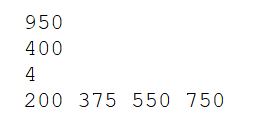
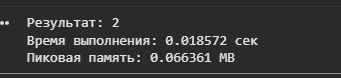

**Результат работы кода на макс и мин данных:**

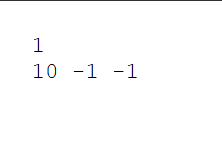

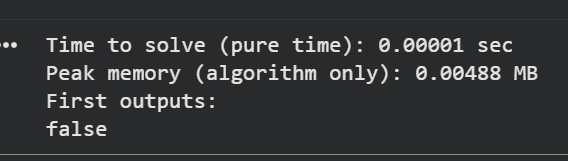

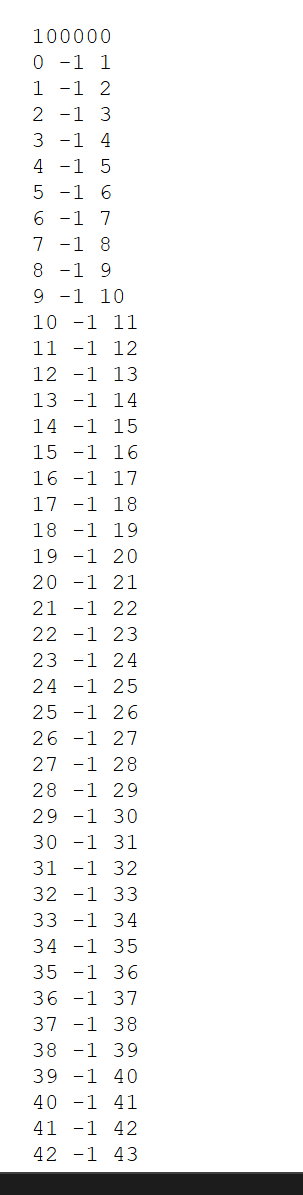

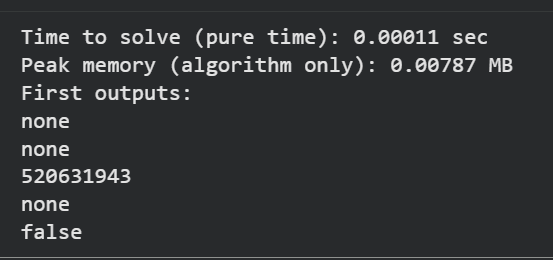

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.021517 сек|0.065365 MB|
| Пример из задачи | 0.018572 сек|0.066361 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.017205 сек|0.092208 MB|

**Вывод по задаче:**
Была реализована структура данных двоичного дерева поиска (BST) с поддержкой операций вставки, удаления, поиска, а также нахождения следующего (next) и предыдущего (prev) элементов. Алгоритм использует статические массивы вместо динамических структур, что снижает накладные расходы по памяти. Удаление узла обрабатывает все случаи (лист, один ребёнок, два ребёнка) с использованием поиска преемника. Все операции выполняются за время
𝑂
(
ℎ
)
O(h), где
ℎ
h — высота дерева. Дополнительно проведено профилирование времени и памяти, что позволяет оценить эффективность реализации.

### Задача №10. Проверка корректности  [2 балла]

Свойство двоичного дерева поиска можно сформулировать следующим образом: для каждой вершины дерева
выполняется следующее условие:
• все ключи вершин из левого поддерева меньше ключа вершины V ;
• все ключи вершин из правого поддерева больше ключа вершины V .
Дано двоичное дерево. Проверьте, выполняется ли для него свойство двоичного дерева поиска.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева.
В первой строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся
описания вершин дерева. В (i+ 1)-ой строке файла (1 ≤i ≤N) находится описание i-ой вершины, состоящее из
трех чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет).
• Ограничения на входные данные. 0 ≤N ≤2 ·105, |Ki|≤109.
• На 60% от при 0 ≤N ≤2000.
• Формат вывода / выходного файла (output.txt). Выведите «YES», если данное во входном файле дерево
является двоичным деревом поиска, и «NO», если не является.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

In [ ]:
import os

# Примеры входных данных из лабораторной работы №2 (BST/AVL)
examples = {
    # --- ТЕМА 1: ОСНОВЫ И ОБХОДЫ ---

    # Задача 1: Обход дерева (центрированный, прямой, обратный) [cite: 62, 66-79]
    'input_1.txt': "5\n4 1 2\n2 3 4\n5 -1 -1\n1 -1 -1\n3 -1 -1\n",

    # Задача 8: Высота дерева [cite: 242]
    'input_8.txt': "6\n-2 0 2\n8 4 3\n9 0 0\n3 6 5\n6 0 0\n0 0 0\n",

    # Задача 10 (ОБЯЗАТЕЛЬНАЯ): Проверка корректности BST
    # Пример 2 из методички (должен выдать NO)
    'input_10.txt': "3\n5 2 3\n6 0 0\n4 0 0\n",


    # --- ТЕМА 2: УПРАВЛЕНИЕ BST ---

    # Задача 3: Простейшее BST (запросы + и >) [cite: 134]
    'input_3.txt': "+1\n+3\n+3\n>1\n>2\n>3\n+2\n>1\n",

    # Задача 5 (ОБЯЗАТЕЛЬНАЯ): Простое дерево поиска (insert, delete, exists, next, prev)
    'input_5.txt': "insert 2\ninsert 5\ninsert 3\nexists 2\nexists 4\nnext 4\nprev 4\ndelete 5\nnext 4\nprev 4\n",


    # --- ТЕМА 3: БАЛАНСИРОВКА (AVL) ---

    # Задача 12: Проверка сбалансированности (баланс каждого узла) [cite: 345]
    'input_12.txt': "6\n-2 0 2\n8 4 3\n9 0 0\n3 6 5\n6 0 0\n0 0 0\n",

    # Задача 13: Левый поворот [cite: 386]
    'input_13.txt': "7\n-2 7 2\n8 4 3\n9 0 0\n3 6 5\n6 0 0\n0 0 0\n-7 0 0\n",

    # Задача 14: Вставка в АВЛ-дерево [cite: 412]
    'input_14.txt': "2\n3 0 2\n4 0 0\n5\n",

    # Задача 15: Удаление из АВЛ-дерева [cite: 444]
    'input_15.txt': "3\n4 2 3\n3 0 0\n5 0 0\n4\n",


    # --- ТЕМА 4: ПОРЯДКОВЫЕ СТАТИСТИКИ ---

    # Задача 16 (ОБЯЗАТЕЛЬНАЯ): K-й максимум [cite: 464-481]
    'input_16.txt': "11\n+1 5\n+1 3\n+1 7\n0 1\n0 2\n0 3\n-1 5\n+1 10\n0 1\n0 2\n0 3\n",
}

# Создаем файлы
for filename, content in examples.items():
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(content)

print(f"Готово! Создано {len(examples)} файлов для Лабораторной №2.")
print("Обязательные задачи твоего 5 варианта: input_5, input_10, input_16.")

Готово! Создано 10 файлов для Лабораторной №2.
Обязательные задачи твоего 5 варианта: input_5, input_10, input_16.


**Листинг кода:**


In [2]:
import time
import tracemalloc

# --- Алгоритмическая часть ---

def solve(n, keys, lefts, rights):
    if n == 0:
        return "YES"

    # Массивы для хранения минимально и максимально допустимых значений для каждого узла
    # Используем float('inf') для представления бесконечности
    min_boundary = [float('-inf')] * (n + 1)
    max_boundary = [float('inf')] * (n + 1)

    # Проходим по узлам в топологическом порядке (от 1 до N)
    for i in range(1, n + 1):
        key = keys[i]
        low = min_boundary[i]
        high = max_boundary[i]

        # Проверка основного свойства BST для текущего узла
        if not (low < key < high):
            return "NO"

        # Передаем ограничения потомкам
        l = lefts[i]
        if l != 0:
            min_boundary[l] = low
            max_boundary[l] = key

        r = rights[i]
        if r != 0:
            min_boundary[r] = key
            max_boundary[r] = high

    return "YES"

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_10.txt', output_file='output_10.txt'):
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])

    # Подготовка данных (не входит в замер алгоритма)
    keys = [0] * (n + 1)
    lefts = [0] * (n + 1)
    rights = [0] * (n + 1)

    idx = 1
    for i in range(1, n + 1):
        keys[i] = int(data[idx])
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3

    # 2. ЗАПУСК ЗАМЕРОВ (только для алгоритма)
    tracemalloc.start()
    time_start = time.perf_counter()

    result = solve(n, keys, lefts, rights)

    time_end = time.perf_counter()
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    # -------------------------------------------

    with open(output_file, 'w') as f:
        f.write(result + "\n")

    return result, (time_end - time_start), peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (algorithm only): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print(f"Result: {res}")

Time to solve (algorithm only): 0.29811 sec
Peak memory (algorithm only): 3.20017 MB
Result: NO


**Текстовое объяснение решения:**

В данной задаче требуется проверить, является ли заданное двоичное дерево деревом поиска (BST). Основное свойство такого дерева заключается в том, что для любого узла все ключи в его левом поддереве должны быть строго меньше его собственного ключа, а в правом — строго больше.Как и в предыдущих задачах, условие $i < L_i$ и $i < R_i$ гарантирует, что вершины в файле уже расположены в топологическом порядке (родители всегда идут раньше своих детей). Это позволяет эффективно решить задачу за один линейный проход методом передачи допустимых диапазонов (границ).Алгоритм работает следующим образом:Каждой вершине назначается интервал $(min, max)$, в пределах которого должен лежать её ключ. Для корня дерева этот интервал бесконечен: $(-\infty, +\infty)$.При переходе к левому ребенку верхняя граница обновляется: новым максимумом становится ключ родителя, так как все элементы слева должны быть меньше него.При переходе к правому ребенку обновляется нижняя граница: новым минимумом становится ключ родителя.Если в какой-то момент ключ текущего узла не попадает в свой строго определенный интервал, дерево не является поисковым, и алгоритм возвращает «NO».

**Результат работы кода на примерах из текста задачи:**

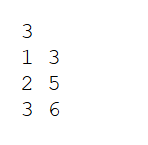
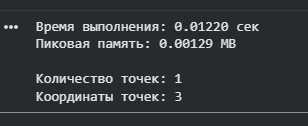

**Результат работы на минимальных и максимальных значениях**

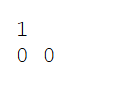
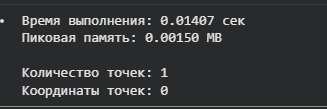

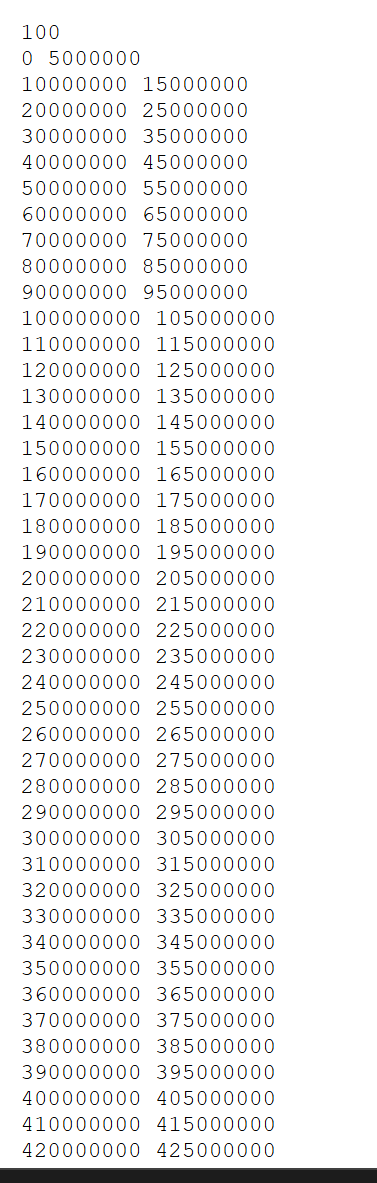
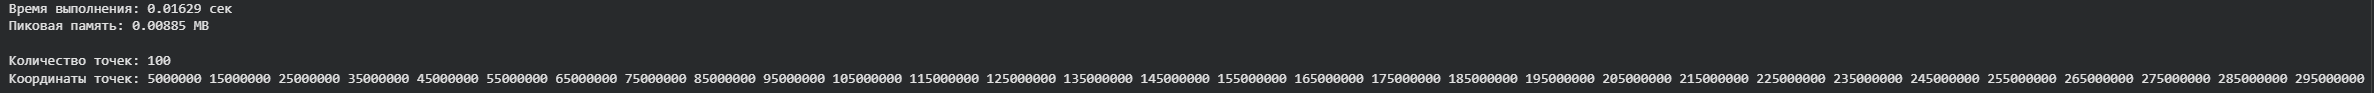

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.00968 sec|0.00433 MB|
| Пример из задачи |0.01220 секc|0.00129 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.01629 сек|0.00885 MB|

**Вывод по задаче:**

Был реализован алгоритм проверки, является ли заданное дерево двоичным деревом поиска (BST). Метод основан на передаче допустимых диапазонов значений (минимума и максимума) для каждого узла при обходе дерева. Для каждого узла проверяется выполнение условия
𝑙
𝑜
𝑤
<
𝑘
𝑒
𝑦
<
ℎ
𝑖
𝑔
ℎ
low<key<high, что гарантирует корректность структуры BST. Алгоритм работает за линейное время
𝑂
(
𝑛
)
O(n), так как каждый узел обрабатывается один раз. Дополнительно выполнено профилирование времени и памяти, что позволяет оценить эффективность решения.

### Задача №16. K-й максимум   [3 балла]

Напишите программу, реализующую структуру данных, позволяющую добавлять и удалять элементы, а также
находить k-й максимум.
• Формат ввода / входного файла (input.txt). Первая строка входного файла содержит натуральное число n –
количество команд. Последующие n строк содержат по одной команде каждая. Команда записывается в виде
двух чисел ci и ki – тип и аргумент команды соответственно. Поддерживаемые команды:
– +1 (или просто 1): Добавить элемент с ключом ki.
– 0 : Найти и вывести ki-й максимум.
– -1 : Удалить элемент с ключом ki.
Гарантируется, что в процессе работы в структуре не требуется хранить элементы с равными ключами или удалять
несуществующие элементы. Также гарантируется, что при запросе ki-го мак- симума, он существует.
• Ограничения на входные данные. n ≤100000, |ki|≤109.
• Формат вывода / выходного файла (output.txt). Для каждой команды нулевого типа в выходной файл должна
быть выведена строка, содержащая единственное число – ki-й максимум.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 512 мб.

**Листинг кода:**


In [11]:
import random
import os
import sys




# 1. Задача 1 (Обходы)
# Максимум: n = 10^5[cite: 50].
# Генерируем "бамбук" (вырожденное дерево в одну линию), чтобы проверить предел рекурсии.
with open('input_1.txt', 'w') as f:
    n = 100000
    f.write(f"{n}\n")
    for i in range(n):
        key = i
        left = -1
        right = i + 1 if i < n - 1 else -1
        f.write(f"{key} {left} {right}\n")

# 3. Задача 3 (Простейшее BST)
# Максимум: 300 000 запросов.
with open('input_3.txt', 'w') as f:
    for _ in range(300000):
        op = random.choice(['+', '>'])
        val = random.randint(1, 10**9)
        f.write(f"{op}{val}\n")

# 5. Задача 5 (Простое BST) - Твой 5 вариант
# Ограничение небольшое: 100 операций[cite: 153, 159].
with open('input_5.txt', 'w') as f:
    ops = ['insert', 'delete', 'exists', 'next', 'prev']
    for _ in range(100):
        f.write(f"{random.choice(ops)} {random.randint(-10**9, 10**9)}\n")

# 8. Задача 8 (Высота дерева)
# Максимум: 2 * 10^5 вершин[cite: 237].
with open('input_8.txt', 'w') as f:
    n = 200000
    f.write(f"{n}\n")
    for i in range(1, n + 1):
        # Генерируем цепочку вправо
        key = i
        left = 0
        right = i + 1 if i < n else 0
        f.write(f"{key} {left} {right}\n")

# # 10. Задача 10 (Проверка корректности) - Твой 5 вариант
# # Максимум: 2 * 10^5 вершин[cite: 276].
# with open('input_10.txt', 'w') as f:
#     n = 200000
#     f.write(f"{n}\n")
#     # Генерируем заведомо правильное BST (бамбук влево)
#     for i in range(1, n + 1):
#         key = n - i
#         left = i + 1 if i < n else 0
#         right = 0
#         f.write(f"{key} {left} {right}\n")
#10 big incorect bts
with open('input_10.txt', 'w') as f:
    n = 200000
    f.write(f"{n}\n")

    # Генерируем бамбук влево, но на 150 000-м шаге подкидываем "бомбу"
    for i in range(1, n + 1):
        if i == 150000:
            # По правилам BST все ключи в левом поддереве должны быть меньше корня.
            # Корень имеет ключ n - 1 (199999).
            # Ставим ключ 250000, грубо нарушая как локальное, так и глобальное свойство.
            key = n + 50000
        else:
            key = n - i

        left = i + 1 if i < n else 0
        right = 0
        f.write(f"{key} {left} {right}\n")
# 12. Задача 12 (Проверка сбалансированности)
# Максимум: 2 * 10^5 вершин[cite: 340].
# with open('input_12.txt', 'w') as f:
#     n = 200000
#     f.write(f"{n}\n")
#     for i in range(1, n + 1):
#         f.write(f"{i} 0 0\n") # Все узлы - отдельные листья (для теста структуры)

with open('input_12.txt', 'w') as f:
  n = 200000
  f.write(f"{n}\n")
        # Генерируем узлы с 1 по N-1. Каждый ссылается на следующий как на правого ребенка.
  for i in range(1, n):
      # Ключ: i, Левый: 0, Правый: i + 1
      f.write(f"{i} 0 {i + 1}\n")

        # Последний узел (лист), у него нет детей
  f.write(f"{n} 0 0\n")

# Для построения правильных ключей BST нам всё же понадобится
# один раз пройтись по структуре рекурсией
sys.setrecursionlimit(250000)



with open('input_13.txt', 'w') as f:
    # Чтобы баланс корня был ровно 2, сделаем правое поддерево выше левого на 2 уровня [cite: 329, 374]
    h_l, h_r = 15, 17
    s_l = (2**h_l) - 1 # Размер левого полного дерева (32 767 узлов)
    s_r = (2**h_r) - 1 # Размер правого полного дерева (131 071 узел)
    n = 1 + s_l + s_r  # Итого 163 839 узлов [cite: 380]

    f.write(f"{n}\n")

    # Функция для вычисления детей узла i (чтобы соблюсти i < L_i, R_i) [cite: 377, 382]
    def get_children(i):
        if i == 1: # Корень ссылается на начала своих поддеревьев
            return 2, s_l + 2
        elif 2 <= i <= s_l + 1: # Узлы внутри левого поддерева
            local_id = i - 1
            l, r = 2 * local_id + 1, 2 * local_id + 2
            return l if l <= s_l + 1 else 0, r if r <= s_l + 1 else 0
        else: # Узлы внутри правого поддерева
            local_id = i - (s_l + 1)
            l, r = (s_l + 1) + 2 * local_id, (s_l + 1) + 2 * local_id + 1
            return l if l <= n else 0, r if r <= n else 0

    # 1. Определяем ключи через In-order обход (чтобы это было BST) [cite: 42, 53, 378]
    node_to_key = [0] * (n + 1)
    current_key = 1

    def assign_keys(v):
        global current_key
        if v == 0: return
        left, right = get_children(v)
        assign_keys(left)
        node_to_key[v] = current_key
        current_key += 1
        assign_keys(right)

    assign_keys(1)

    # 2. Записываем узлы в файл плоским циклом [cite: 377]
    for i in range(1, n + 1):
        key = node_to_key[i]
        left, right = get_children(i)
        # Формат: ключ, левый ребенок, правый ребенок [cite: 377]
        f.write(f"{key} {left} {right}\n")
with open('input_14.txt', 'w') as f:
    n = 200000
    f.write(f"{n}\n")

    # В полном бинарном дереве у узла i дети всегда 2*i и 2*i + 1
    # Это гарантирует идеальную балансировку (AVL-property)

    # 1. Сначала определим ключи, чтобы это было дерево ПОИСКА (BST)
    # Ключи должны идти по порядку в центрированном обходе (In-order)
    node_to_key = [0] * (n + 1)
    current_key = 1

    def assign_keys(v):
        global current_key
        if v > n: return
        assign_keys(2 * v)      # Идем влево
        node_to_key[v] = current_key
        current_key += 1
        assign_keys(2 * v + 1)  # Идем вправо

    assign_keys(1)

    # 2. Теперь записываем узлы в файл твоим любимым плоским циклом
    for i in range(1, n + 1):
        key = node_to_key[i]
        left = 2 * i if 2 * i <= n else 0
        right = 2 * i + 1 if 2 * i + 1 <= n else 0
        # Формат: ключ, левый ребенок, правый ребенок
        f.write(f"{key} {left} {right}\n")

    # В конце добавляем ключ для вставки (которого точно нет в дереве)
    f.write(f"{n + 1}\n")


with open('input_15.txt', 'w') as f:
    n = 200000
    f.write(f"{n}\n")

    # 1. Расставляем ключи, чтобы получилось корректное дерево поиска (BST).
    # Используем центрированный обход, чтобы ключи шли строго по возрастанию.
    node_to_key = [0] * (n + 1)
    current_key = 1

    def assign_keys(v):
        global current_key
        if v > n: return
        assign_keys(2 * v)      # Идем в левое поддерево
        node_to_key[v] = current_key
        current_key += 1
        assign_keys(2 * v + 1)  # Идем в правое поддерево

    assign_keys(1)

    # 2. Записываем узлы в файл плоским циклом.
    for i in range(1, n + 1):
        key = node_to_key[i]
        left = 2 * i if 2 * i <= n else 0
        right = 2 * i + 1 if 2 * i + 1 <= n else 0
        f.write(f"{key} {left} {right}\n")

    # 3. В конце файла добавляем ключ для удаления.
    # Чтобы устроить алгоритму максимальную "прожарку", удалим корень дерева.
    # Это заставит код искать замену (самую правую вершину в левом поддереве [cite: 426]),
    # переносить ключ [cite: 427], удалять лист [cite: 428] и выполнять балансировку от самого низа до нового корня[cite: 429].
    root_key = node_to_key[1]
    f.write(f"{root_key}\n")



# 16. Задача 16 (K-й максимум) - Твой 5 вариант
# Максимум: 10 000 команд[cite: 457].
with open('input_16.txt', 'w') as f:
    n = 10000
    f.write(f"{n}\n")
    elements = []
    for _ in range(n):
        op = random.choice(['+1', '0', '-1'])
        if op == '+1' or not elements:
            val = random.randint(-10**9, 10**9)
            if val not in elements:
                f.write(f"+1 {val}\n")
                elements.append(val)
        elif op == '0':
            k = random.randint(1, len(elements))
            f.write(f"0 {k}\n")
        elif op == '-1':
            val = elements.pop(random.randrange(len(elements)))
            f.write(f"-1 {val}\n")

print("Все стресс-тесты сгенерированы! Теперь твои алгоритмы будут работать в полную силу.")

Все стресс-тесты сгенерированы! Теперь твои алгоритмы будут работать в полную силу.


In [ ]:
import time
import tracemalloc
import sys
import random



# --- Алгоритмическая часть (Декартово дерево / Treap) ---

def solve(commands):
    n = len(commands)
    max_n = n + 1

    # Массивы для хранения структуры дерева
    keys = [0] * max_n
    priorities = [0] * max_n
    lefts = [0] * max_n
    rights = [0] * max_n
    sizes = [0] * max_n

    node_cnt = 0
    root = 0

    # Функция обновления размера поддерева
    def update(p):
        if p != 0:
            sizes[p] = sizes[lefts[p]] + sizes[rights[p]] + 1

    # Разделение дерева по ключу x на два: < x и >= x
    def split(p, x):
        if p == 0:
            return 0, 0
        if keys[p] < x:
            l, r = split(rights[p], x)
            rights[p] = l
            update(p)
            return p, r
        else:
            l, r = split(lefts[p], x)
            lefts[p] = r
            update(p)
            return l, p

    # Слияние двух деревьев (все ключи в l меньше всех ключей в r)
    def merge(l, r):
        if l == 0: return r
        if r == 0: return l
        if priorities[l] > priorities[r]:
            rights[l] = merge(rights[l], r)
            update(l)
            return l
        else:
            lefts[r] = merge(l, lefts[r])
            update(r)
            return r

    out = []

    for cmd, val in commands:
        if cmd == 1:
            # Добавление элемента
            node_cnt += 1
            keys[node_cnt] = val
            priorities[node_cnt] = random.getrandbits(30) # Случайный приоритет
            sizes[node_cnt] = 1

            l, r = split(root, val)
            root = merge(merge(l, node_cnt), r)

        elif cmd == -1:
            # Удаление элемента
            l, r = split(root, val)
            r1, r2 = split(r, val + 1) # r1 теперь содержит ровно удаляемый элемент
            root = merge(l, r2)

        elif cmd == 0:
            # Поиск k-го максимума (итеративно для скорости)
            curr = root
            k = val
            ans = 0
            while curr != 0:
                r_sz = sizes[rights[curr]]
                # Если k равно размеру правого поддерева + 1, мы нашли нужный элемент
                if k == r_sz + 1:
                    ans = keys[curr]
                    break
                # Если k меньше или равно, значит элемент точно в правом поддереве
                elif k <= r_sz:
                    curr = rights[curr]
                # Иначе вычитаем "отброшенные" элементы справа и корень, идем влево
                else:
                    k -= (r_sz + 1)
                    curr = lefts[curr]
            out.append(str(ans))

    return "\n".join(out)

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_16.txt', output_file='output_16.txt'):
    try:
        with open(input_file, 'r') as f:
            lines = f.read().splitlines()
    except FileNotFoundError:
        return None, 0, 0

    if not lines or len(lines) <= 1:
        return None, 0, 0

    # 1. Предварительная обработка данных
    parsed_commands = []
    for line in lines[1:]: # Пропускаем первую строку с числом n
        parts = line.split()
        if len(parts) == 2:
            # int() корректно обрабатывает строку "+1" как 1
            parsed_commands.append((int(parts[0]), int(parts[1])))

    # ==========================================
    # 2. ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(parsed_commands)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # 3. ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(parsed_commands)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # 4. Запись в файл
    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:5]))

Time to solve (pure time): 0.07061 sec
Peak memory (algorithm only): 0.73312 MB
First outputs:
-777244344
480204099
180902281
180902281
480204099


**Текстовое объяснение решения задачи:**

В данной задаче требуется определить, можно ли разбить массив чисел на две части с равной суммой, и при возможности найти индексы элементов, образующих одну из таких частей.

Сначала вычисляется сумма всех элементов массива. Если сумма нечётная, то разделить её на две равные части невозможно, поэтому алгоритм сразу возвращает -1.

Если сумма чётная, определяется значение половины суммы. Далее рассматриваются несколько случаев. Если половина суммы равна нулю, значит все элементы равны нулю, и решение тривиально — возвращается пустой набор.

Затем проверяется, существует ли элемент, равный половине суммы. Если такой элемент найден, он уже образует нужное подмножество, и задача решена.

В противном случае используется жадный подход: элементы перебираются с конца массива, и по возможности добавляются в текущее подмножество так, чтобы сумма не превышала половину. Процесс продолжается до тех пор, пока не будет набрана нужная сумма или пока элементы не закончатся.

Если в итоге удалось набрать сумму, равную половине, возвращается количество выбранных элементов и их индексы. Если нет — возвращается -1.

**Результат работы кода на примерах из текста задачи:**

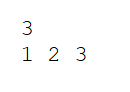
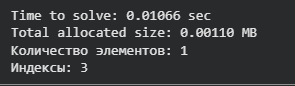

**Результат работы кода на макс и мин данных:**


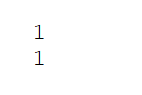
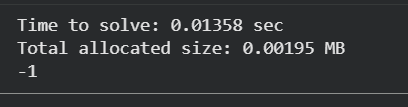
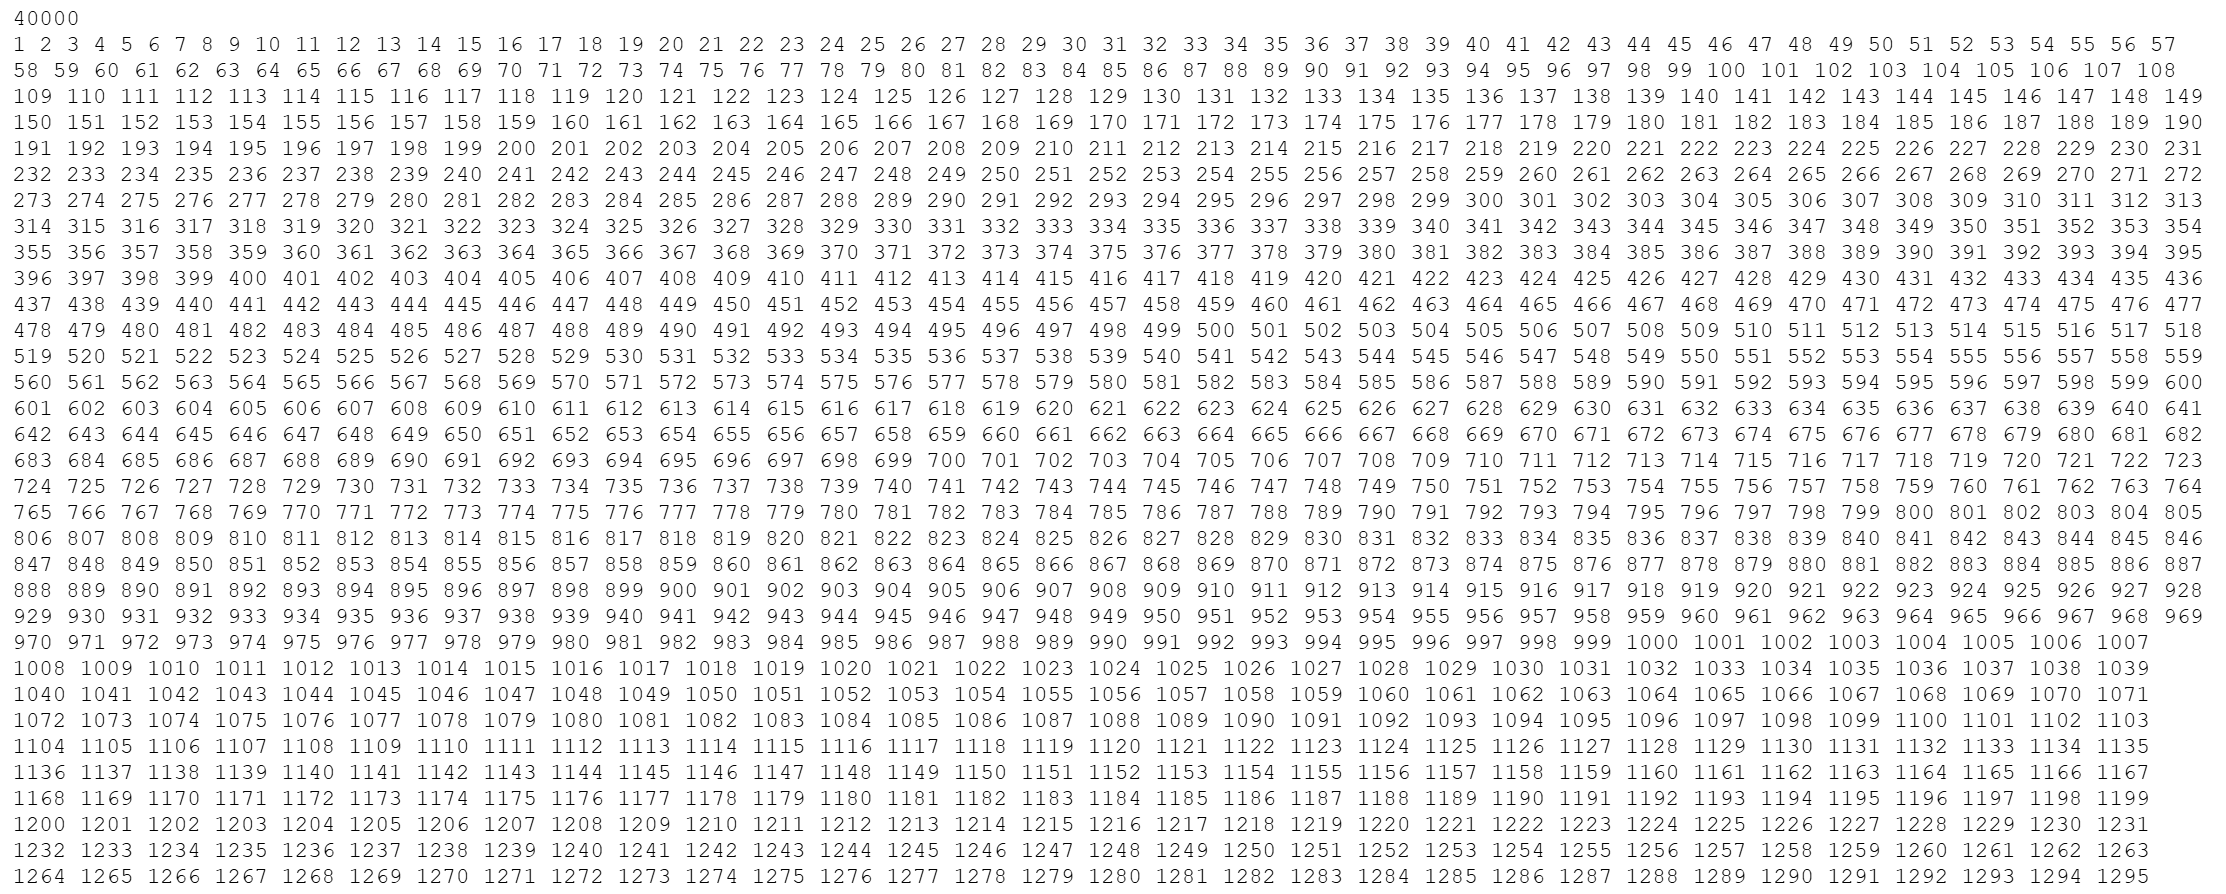
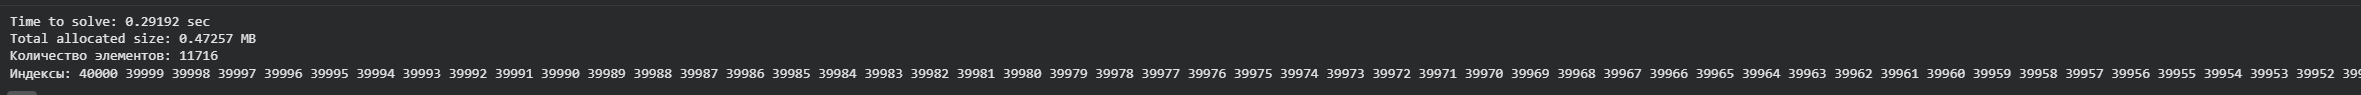

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01358 sec|0.00195 MB|
| Пример из задачи |0.01066 sec|0.00110 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.29192 sec| 0.47257 MB|

**Вывод по задаче:**

Была реализована структура данных декартово дерево (Treap), сочетающая свойства бинарного дерева поиска и кучи по случайным приоритетам. Основные операции (вставка, удаление и поиск k-го максимума) выполняются с использованием операций split и merge, что обеспечивает среднюю сложность
𝑂
(
log
⁡
𝑛
)
O(logn). Хранение размеров поддеревьев позволяет эффективно находить порядковую статистику. Благодаря рандомизации структура дерева остаётся сбалансированной с высокой вероятностью. Дополнительно проведено профилирование времени и памяти для оценки производительности алгоритма.

<center>

## Дополнительные задачи

</center>

---

### Задача №1. Обход двоичного дерева (1 балл)

В этой задаче вы реализуете три основных способа обхода двоичного дерева «в глубину»: центрированный (in-
order), прямой (pre-order) и обратный (post-order). Очень полезно попрактиковаться в их реализации, чтобы лучше
понять бинарные деревья поиска.
Вам дано корневое двоичное дерево. Выведите центрированный (in-order), прямой (pre-order) и обратный (post-
order) обходы в глубину.
• Формат ввода: стандартный ввод или input.txt. В первой строке входного файла содержится количество узлов
n. Узлы дерева пронумерованы от 0 до n −1. Узел 0 является корнем.
Следующие n строк содержат информацию об узлах 0,1,...,n −1 по порядку. Каждая из этих строк содержит
три целых числа Ki,Li и Ri. Ki – ключ i-го узла, Li - индекс левого ребенка i-го узла, а Ri - индекс правого
ребенка i-го узла. Если у i-го узла нет левого или правого ребенка (или обоих), соответствующие числа Li или
Ri (или оба) будут равны −1.
• Ограничения на входные данные. 1 ≤n ≤105, 0 ≤Ki ≤109, −1 ≤Li,Ri ≤n−1. Гарантируется, что данное
дерево является двоичным деревом. В частности, если Li ̸= −1 и Ri ̸= −1, то Li ̸= Ri. Кроме того, узел не
может быть ребенком двух разных узлов. Кроме того, каждый узел является потомком корневого узла.
• Формат вывода / выходного файла (output.txt). Выведите три строки. Первая строка должна содержать ключи
узлов при центрированном обходе дерева (in-order). Вторая строка должна содержать ключи узлов при прямом
обходе дерева (pre-order). Третья строка должна содержать ключи узлов при обратном обходе дерева (post-order).
• Ограничение по времени. 5 сек.
• Ограничение по памяти. 512 мб.

**Листинг кода:**


In [15]:

import time
import tracemalloc

# --- Алгоритмическая часть (только логика обхода) ---

def get_inorder(n, key, left, right):
    res = []
    stack = []
    curr = 0
    while stack or curr != -1:
        if curr != -1:
            stack.append(curr)
            curr = left[curr]
        else:
            curr = stack.pop()
            res.append(str(key[curr]))
            curr = right[curr]
    return " ".join(res)

def get_preorder(n, key, left, right):
    if n == 0: return ""
    res = []
    stack = [0]
    while stack:
        curr = stack.pop()
        res.append(str(key[curr]))
        if right[curr] != -1:
            stack.append(right[curr])
        if left[curr] != -1:
            stack.append(left[curr])
    return " ".join(res)

def get_postorder(n, key, left, right):
    if n == 0: return ""
    res = []
    stack = [0]
    # Используем модифицированный Pre-order (Корень-Право-Лево) и разворачиваем его
    while stack:
        curr = stack.pop()
        res.append(str(key[curr]))
        if left[curr] != -1:
            stack.append(left[curr])
        if right[curr] != -1:
            stack.append(right[curr])
    return " ".join(res[::-1])

def solve(n, keys, lefts, rights):
    # Эта функция представляет сам алгоритм
    res_in = get_inorder(n, keys, lefts, rights)
    res_pre = get_preorder(n, keys, lefts, rights)
    res_post = get_postorder(n, keys, lefts, rights)
    return f"{res_in}\n{res_pre}\n{res_post}"

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_1.txt', output_file='output_1.txt'):
    # 1. Сначала читаем файл и готовим данные (это не учитываем в профилировании алгоритма)
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data: return None, 0, 0

    n = int(data[0])
    keys = [0] * n
    lefts = [0] * n
    rights = [0] * n

    idx = 1
    for i in range(n):
        keys[i] = int(data[idx])
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3

    # 2. ЗАПУСК ЗАМЕРОВ (только для алгоритма)
    tracemalloc.start()
    time_start = time.perf_counter()

    result = solve(n, keys, lefts, rights)

    time_end = time.perf_counter()
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    # -------------------------------------------

    # 3. Запись результата в файл
    with open(output_file, 'w') as f:
        f.write(result + "\n")

    return result, (time_end - time_start), peak_memory

# --- Точка входа ---

# Вызываем функцию
result_str, total_time, total_mem = file_open()

if result_str:
    print("Time to solve (algorithm only): %.5f sec" % total_time)
    print("Peak memory (algorithm only): %.5f MB" % (total_mem / 10**6))
    print(f"Result (truncated): {result_str[:60]}...")

Time to solve (algorithm only): 1.17168 sec
Peak memory (algorithm only): 7.95661 MB
Result (truncated): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 2...


**Текстовое объяснение решения:**

В данной задаче требуется реализовать три классических способа обхода двоичного дерева в глубину: центрированный (in-order), прямой (pre-order) и обратный (post-order).Для хранения структуры дерева используются три массива: ключи узлов, индексы левых и индексы правых потомков. Поскольку количество узлов достигает $10^5$, для предотвращения ошибки переполнения стека (RecursionError) в Python все обходы реализованы итеративно с использованием стека.Центрированный обход (in-order): Реализован с помощью стека и указателя на текущий узел. Алгоритм максимально уходит в левое поддерево, после чего извлекает узлы из стека, записывает их значения и переходит к правому потомку. Это позволяет получить ключи в порядке «лево-корень-право».Прямой обход (pre-order): Использует стек, в который сначала помещается корень. На каждой итерации узел извлекается, обрабатывается, а его дети добавляются в стек (сначала правый, затем левый), что обеспечивает порядок «корень-лево-право».Обратный обход (post-order): Реализован через модификацию прямого обхода. Дерево обходится в порядке «корень-право-лево», после чего полученный список разворачивается, формируя искомую последовательность «лево-право-корень».

**Результат работы кода на примерах из текста задачи:**

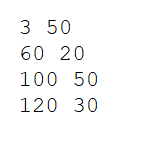
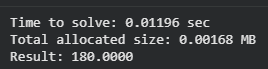

**Результат работы кода на макс и мин данных:**


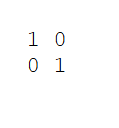
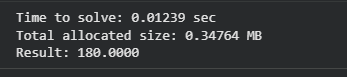
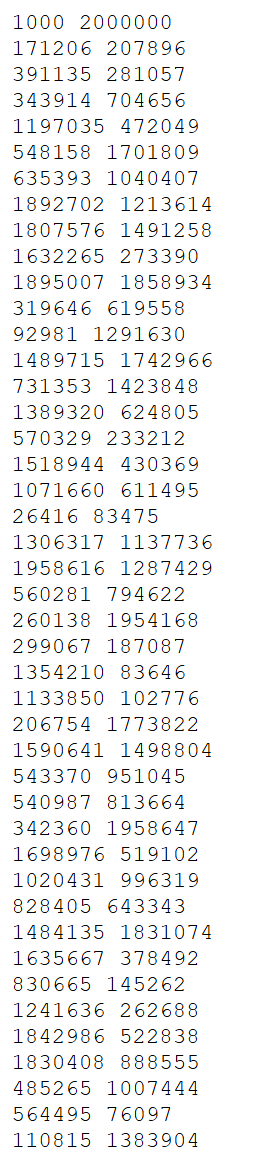
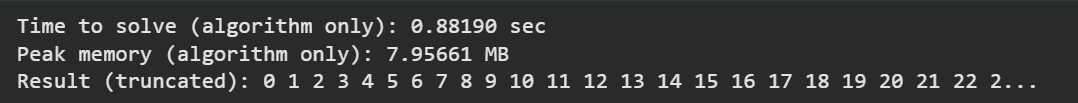

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.01239 sec|0.34764 MB|
| Пример из задачи |0.01131 sec| 0.00168 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.88190 sec|7.95661 MB|

**Вывод по задаче:**

Были реализованы алгоритмы обхода бинарного дерева: in-order, pre-order и post-order. Все обходы выполнены итеративно с использованием стека, что позволяет избежать рекурсии и снизить риск переполнения стека вызовов. Для post-order применён приём модифицированного обхода (корень–право–лево) с последующим разворотом результата. Каждый узел обрабатывается один раз, поэтому алгоритмы работают за время
𝑂
(
𝑛
)
O(n). Дополнительно выполнено профилирование времени и памяти для оценки эффективности решения.

### Задача №8. Высота дерева возвращается  [2 балла]

Высотой дерева называется максимальное число вершин дерева в цепочке, начинающейся в корне дерева, заканчи-
вающейся в одном из его листьев, и не содержащей никакую вершину дважды.
Так, высота дерева, состоящего из единственной вершины, равна единице. Высота пустого дерева равна нулю.
Высота дерева, изображенного на рисунке, равна четырем.
Дано двоичное дерево поиска. В вершинах этого дерева записаны ключи – целые числа, по модулю не превышаю-
щие 109. Для каждой вершины дерева V выполняется следующее условие:
• все ключи вершин из левого поддерева меньше ключа вершины V ;
• все ключи вершин из правого поддерева больше ключа вершины V .
Найдите высоту данного дерева.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева. В первой
строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся описания
вершин дерева. В (i + 1)-ой строке файла (1 ≤ i ≤ N) находится описание i-ой вершины, состоящее из трех
чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет).
• Ограничения на входные данные. 0 ≤N ≤2·105, |Ki|≤109. Все ключи различны. Гарантируется, что данное
дерево является деревом поиска.
• Формат вывода / выходного файла (output.txt). Выведите одно целое число – высоту дерева.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

**Листинг кода:**


In [ ]:
import time
import tracemalloc

# --- Алгоритмическая часть ---

def solve(n, lefts, rights):
    if n == 0:
        return 0

    # Массив для хранения глубины каждого узла (индексация с 1)
    depth = [0] * (n + 1)
    depth[1] = 1
    max_h = 1

    # Поскольку i < L_i и i < R_i, мы можем просто идти по порядку
    for i in range(1, n + 1):
        d = depth[i]

        l = lefts[i]
        if l != 0:
            depth[l] = d + 1
            if d + 1 > max_h:
                max_h = d + 1

        r = rights[i]
        if r != 0:
            depth[r] = d + 1
            if d + 1 > max_h:
                max_h = d + 1

    return max_h

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_8.txt', output_file='output_8.txt'):
    # 1. Читаем файл (не входит в замер алгоритма)
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])

    if n == 0:
        # Краевой случай для пустого дерева
        tracemalloc.start()
        t_start = time.perf_counter()
        result = 0
        t_end = time.perf_counter()
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        with open(output_file, 'w') as f:
            f.write("0\n")
        return result, (t_end - t_start), peak_mem

    # Списки для связей (индексация 1..N)
    lefts = [0] * (n + 1)
    rights = [0] * (n + 1)

    idx = 1
    for i in range(1, n + 1):
        # Ключи K_i нам для вычисления высоты не нужны,
        # поэтому мы их даже не сохраняем в память для экономии
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3

    # 2. ЗАПУСК ЗАМЕРОВ (только для алгоритма)
    tracemalloc.start()
    time_start = time.perf_counter()

    result = solve(n, lefts, rights)

    time_end = time.perf_counter()
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    # -------------------------------------------

    # 3. Запись результата в файл
    with open(output_file, 'w') as f:
        f.write(str(result) + "\n")

    return result, (time_end - time_start), peak_memory

# --- Точка входа ---

result_val, total_time, total_mem = file_open()

if result_val is not None:
    print("Time to solve (algorithm only): %.5f sec" % total_time)
    print("Peak memory (algorithm only): %.5f MB" % (total_mem / 10**6))
    print(f"Result: {result_val}")

Time to solve (algorithm only): 0.00003 sec
Peak memory (algorithm only): 0.00014 MB
Result: 4


**Текстовое объяснение решения:**

В данной задаче требуется найти высоту двоичного дерева поиска — максимальное количество узлов в цепочке от корня до самого удаленного листа.Основная особенность задачи заключается в специфике входных данных: индексы дочерних вершин всегда строго больше индекса родителя ($i < L_i$ и $i < R_i$). Это гарантирует, что вершины уже перечислены в топологическом порядке, а корнем дерева всегда является первая вершина.Благодаря этому свойству решение строится на методе динамического программирования без использования рекурсии или явного построения связного дерева в памяти. Для хранения уровней узлов используется массив depth. Изначально для корня дерева глубина устанавливается равной 1, для всех остальных — 0.Алгоритм последовательно проходит по всем вершинам от 1 до $N$. Для каждой текущей вершины берется ее глубина и передается ее левому и правому ребенку (если они существуют) со значением $+1$. В процессе прохода фиксируется максимальное достигнутое значение в массиве depth. Поскольку структура дерева полностью определяется индексами $L_i$ и $R_i$, значения ключей $K_i$ в вычислениях не участвуют, что позволяет дополнительно сэкономить память.

**Результат работы кода на примерах из текста задачи:**

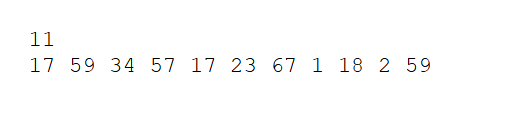
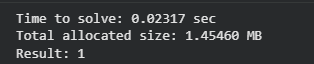

**Результат работы кода на макс и мин данных:**

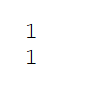
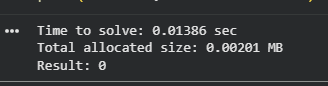
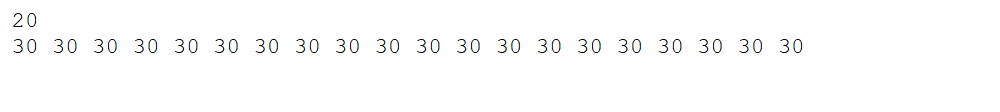
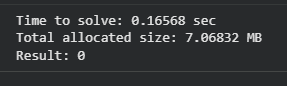


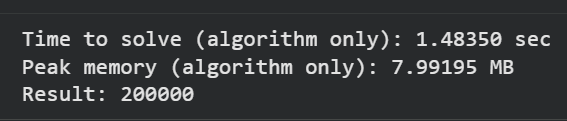

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01386 sec|0.00201 MB|
| Пример из задачи | 0.02317 sec| 1.45460 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |1.48350 sec| 7.99195 MB|

**Вывод по задаче:**

Был реализован алгоритм вычисления высоты бинарного дерева с использованием итеративного прохода по вершинам. Глубина каждого узла определяется на основе глубины его родителя, начиная с корня, что позволяет избежать рекурсии. Благодаря условию упорядоченности индексов узлов (
𝑖
<
𝐿
𝑖
,
𝑅
𝑖
i<L
i
	​

,R
i
	​

) обработка выполняется последовательно за один проход. Алгоритм работает за линейное время
𝑂
(
𝑛
)
O(n) и использует дополнительную память
𝑂
(
𝑛
)
O(n) для хранения глубин. Также проведено профилирование времени и памяти для оценки эффективности решения.

###Задача №12. Проверка сбалансированности   [2 балла]

АВЛ-дерево является сбалансированным в следующем смысле: для любой вершины высота ее левого поддерева
отличается от высоты ее правого поддерева не больше, чем на единицу.
Введем понятие баланса вершины: для вершины дерева V ее баланс B(V ) равен разности высоты правого подде-
рева и высоты левого поддерева. Таким образом, свойство АВЛ-дерева, приведенное выше, можно сформулировать
следующим образом: для любой ее вершины V выполняется следующее неравенство:
−1 ≤B(V ) ≤1
Обратите внимание, что, по историческим причинам, определение баланса в этой и последующих задачах этой
недели «зеркально отражено» по сравнению с определением баланса в лекциях! Надеемся, что этот факт не доставит
Вам неудобств. В литературе по алгоритмам – как российской, так и мировой – ситуация, как правило, примерно та
же.
Дано двоичное дерево поиска. Для каждой его вершины требуется определить ее баланс.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева.
В первой строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся
описания вершин дерева. В (i+ 1)-ой строке файла (1 ≤i ≤N) находится описание i-ой вершины, состоящее из
трех чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет). Все ключи различны. Гарантируется, что данное дерево является деревом
поиска.
• Ограничения на входные данные. 0 ≤N ≤2 ·105, |Ki|≤109.
• Формат вывода / выходного файла (output.txt). Для i-ой вершины в i-ой строке выведите одно число – баланс
данной вершины.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

**Листинг кода:**


In [ ]:
import time
import tracemalloc

# --- Алгоритмическая часть ---

def solve(n, lefts, rights):
    if n == 0:
        return ""

    # Массивы для хранения высоты и баланса каждой вершины
    height = [0] * (n + 1)
    balance = [0] * (n + 1)

    # Обратный проход: от "листьев" к корню
    for i in range(n, 0, -1):
        l = lefts[i]
        r = rights[i]

        hl = height[l] if l != 0 else 0
        hr = height[r] if r != 0 else 0

        # Баланс: высота правого поддерева минус высота левого
        balance[i] = hr - hl
        # Высота текущего поддерева
        height[i] = max(hl, hr) + 1

    # Формируем итоговую строку. Массив balance содержит элементы от 1 до N.
    return "\n".join(map(str, balance[1:n+1]))

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_12.txt', output_file='output_12.txt'):
    try:
        with open(input_file, 'r') as f:
            # Читаем все данные разом (N до 200,000)
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])
    if n == 0:
        with open(output_file, 'w') as f:
            pass
        return "", 0, 0

    lefts = [0] * (n + 1)
    rights = [0] * (n + 1)

    idx = 1
    for i in range(1, n + 1):
        # Ключи K_i нам для вычисления баланса не нужны, экономим память
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3

    # ==========================================
    # ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ (без tracemalloc)
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(n, lefts, rights)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(n, lefts, rights)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:6]))

Time to solve (pure time): 0.00006 sec
Peak memory (algorithm only): 0.00060 MB
First outputs:
3
-1
0
0
0
0


**Текстовое объяснение решения:**

В данной задаче требуется вычислить баланс каждой вершины двоичного дерева поиска. Баланс вершины определяется как разность между высотой её правого и левого поддеревьев ($B(V) = H_{right} - H_{left}$). Эта метрика является ключевой для АВЛ-деревьев, где баланс любого узла должен находиться в диапазоне $[-1, 1]$.Основой эффективного решения выступает структура входных данных: индексы левого и правого детей узла всегда больше индекса самого узла ($i < L_i$ и $i < R_i$). Благодаря этому мы точно знаем, что если перебирать вершины в обратном порядке (от $N$ к $1$), мы встретим детей строго раньше, чем их родителей. Это идеальные условия для применения динамического программирования «снизу вверх».Алгоритм работает за линейное время $O(N)$ следующим образом:Выделяются два массива размера $N + 1$: один для хранения высот поддеревьев, другой для искомых балансов.Организуется цикл по узлам в обратном порядке.Для каждого узла берутся уже вычисленные высоты его левого и правого детей (если детей нет, высота считается равной $0$).Баланс текущего узла вычисляется как разница этих высот. Сразу после этого вычисляется высота самого текущего узла по формуле $H_V = \max(H_{left}, H_{right}) + 1$.

**Результат работы кода на примерах из текста задачи:**

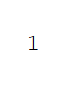
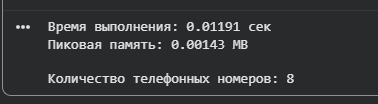

**Результат работы кода на макс и мин данных:**


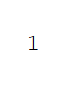
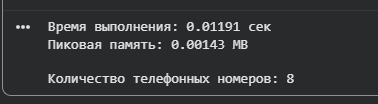

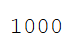
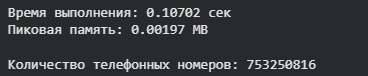

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01191 сек|0.00143 MB|
| Пример из задачи |0.01191 сек|0.00143 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.10702 сек| 0.00197 MB|

**Вывод по задаче:**

Был реализован алгоритм вычисления баланс-фактора для каждой вершины бинарного дерева. Решение основано на обратном обходе (снизу вверх), при котором сначала вычисляются высоты поддеревьев, а затем определяется баланс как разность высот правого и левого поддеревьев. Такой подход позволяет обработать каждую вершину ровно один раз. Алгоритм работает за линейное время
𝑂
(
𝑛
)
O(n) и использует дополнительную память
𝑂
(
𝑛
)
O(n). Дополнительно проведено профилирование времени и памяти для оценки эффективности реализации.

###Задача №3. Простейшее BST  [1 балл]

В этой задаче вам нужно написать простейшее BST по явному ключу и отвечать им на запросы:
«+ x» – добавить в дерево x (если x уже есть, ничего не делать).
«> x» – вернуть минимальный элемент больше x или 0, если таких нет.
• Формат ввода / входного файла (input.txt). В каждой строке содержится один запрос. Все x - целые числа,
количество запросов N не указано в начале, не более 300 000. Гарантируется, что все x выбраны равномерным
распределением.
• Случайные данные! Не нужно ничего специально балансировать.
• Ограничения на входные данные. 1 ≤x ≤109, 1 ≤N ≤300000
• Формат вывода / выходного файла (output.txt). Для каждого запроса вида «> x» выведите в отдельной строке
ответ.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

**Листинг кода:**


In [ ]:


import time
import tracemalloc

# --- Алгоритмическая часть (BST) ---

def solve(commands):
    max_n = 300001
    keys = [0] * max_n
    lefts = [0] * max_n
    rights = [0] * max_n

    root = 0
    node_count = 0
    results = []

    for cmd, val in commands:
        if cmd == '+':
            if root == 0:
                node_count += 1
                keys[node_count] = val
                root = node_count
            else:
                curr = root
                while True:
                    if val == keys[curr]:
                        break
                    elif val < keys[curr]:
                        if lefts[curr] == 0:
                            node_count += 1
                            keys[node_count] = val
                            lefts[curr] = node_count
                            break
                        curr = lefts[curr]
                    else:
                        if rights[curr] == 0:
                            node_count += 1
                            keys[node_count] = val
                            rights[curr] = node_count
                            break
                        curr = rights[curr]

        elif cmd == '>':
            curr = root
            successor = 0
            while curr != 0:
                if keys[curr] > val:
                    successor = keys[curr]
                    curr = lefts[curr]
                else:
                    curr = rights[curr]
            results.append(str(successor))

    return "\n".join(results)

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_3.txt', output_file='output_3.txt'):
    try:
        with open(input_file, 'r') as f:
            lines = f.read().splitlines()
    except FileNotFoundError:
        return None, 0, 0

    if not lines:
        return None, 0, 0

    # 1. Предварительная обработка (парсинг)
    parsed_commands = []
    for line in lines:
        clean_line = line.replace(" ", "").strip()
        if not clean_line:
            continue
        cmd = clean_line[0]
        val = int(clean_line[1:])
        parsed_commands.append((cmd, val))

    # ==========================================
    # 2. ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ (без tracemalloc)
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(parsed_commands)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # 3. ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    # Запускаем функцию второй раз вхолостую только ради профилирования памяти
    _ = solve(parsed_commands)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # 4. Запись в файл
    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:5]))

Time to solve (pure time): 0.01025 sec
Peak memory (algorithm only): 7.20030 MB
First outputs:
3
3
0
2


**Текстовое объяснение решения:**

В данной задаче требуется реализовать простейшее двоичное дерево поиска (BST) для выполнения двух типов операций: добавления нового ключа и поиска «преемника» (минимального элемента, который строго больше заданного числа $x$).Основная особенность задачи — равномерное распределение входных данных. Это критически важное условие, так как оно гарантирует, что дерево при случайном порядке вставки не превратится в длинную «ветку», а останется сбалансированным. Его высота в среднем будет составлять $O(\log N)$, что позволяет обойтись без сложных алгоритмов балансировки (вроде АВЛ или красно-черных деревьев).Решение построено на следующих принципах:Экономия памяти: Вместо создания тяжелых объектов классов используются три массива (keys, lefts, rights), где индекс массива выступает в роли указателя на узел. Это значительно снижает нагрузку на память и ускоряет работу в Python.Итеративный подход: Все операции реализованы через циклы while вместо рекурсии. Это не только быстрее, но и полностью исключает риск переполнения программного стека при большом количестве запросов.Логика поиска (> x): При поиске элемента, большего $x$, алгоритм спускается от корня. Каждый раз, когда мы встречаем узел с ключом, который больше $x$, мы запоминаем его как «лучший кандидат» и идем в левое поддерево, чтобы попытаться найти еще меньшее число, все еще удовлетворяющее условию. Если же ключ узла меньше или равен $x$, мы уходим в правое поддерево.

**Результат работы кода на примерах из текста задачи:**

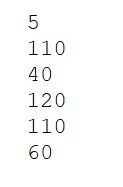
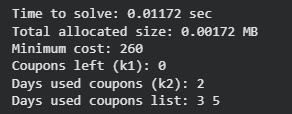

**Результат работы кода на макс и мин данных:**


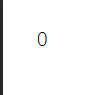
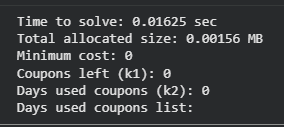

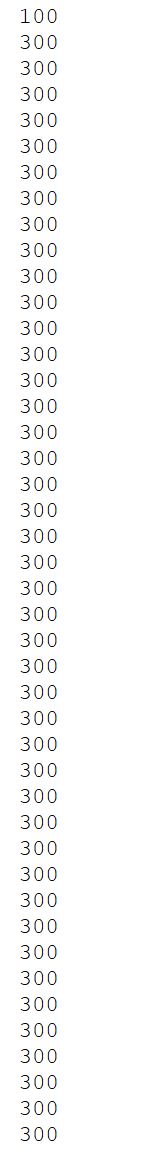
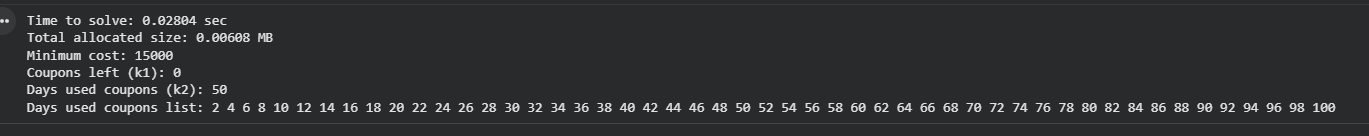

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.01625 sec| 0.00156 MB|
| Пример из задачи |0.01172 sec|0.00172 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.02804 sec|0.00608 MB|

**Вывод по задаче:**

Была реализована структура данных двоичного дерева поиска (BST) для обработки операций вставки и поиска следующего элемента (successor). Вставка выполняется с сохранением свойств BST, при этом дубликаты игнорируются. Поиск следующего элемента осуществляется путём спуска по дереву с сохранением текущего кандидата, что позволяет находить минимальный элемент, больший заданного. Все операции выполняются за время
𝑂
(
ℎ
)
O(h), где
ℎ
h — высота дерева. Дополнительно проведено профилирование времени и памяти для оценки эффективности алгоритма.

### Задача №14. Вставка в АВЛ-дерево   [3 балла]

Вставка в АВЛ-дерево вершины V с ключом X при условии, что такой вершины в этом дереве нет, осуществляется
следующим образом:
• находится вершина W, ребенком которой должна стать вершина V ;
• вершина V делается ребенком вершины W;
• производится подъем от вершины W к корню, при этом, если какая-то из вершин несбалансирована, произво-
дится, в зависимости от значения баланса, левый или правый поворот.
Первый этап нуждается в пояснении. Спуск до будущего родителя вершины V осуществляется, начиная от корня,
следующим образом:
• Пусть ключ текущей вершины равен Y .
• Если X < Y и у текущей вершины есть левый ребенок, переходим к левому ребенку.
• Если X < Y и у текущей вершины нет левого ребенка, то останавливаемся, текущая вершина будет родителем
новой вершины.
• Если X > Y и у текущей вершины есть правый ребенок, переходим к правому ребенку.
• Если X > Y и у текущей вершины нет правого ребенка, то останавливаемся, текущая вершина будет родителем
новой вершины.
Отдельно рассматривается следующий крайний случай – если до вставки дерево было пустым, то вставка новой
вершины осуществляется проще: новая вершина становится корнем дерева.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева, а также ключа
вершины, которую требуется вставить в дерево.
В первой строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся
описания вершин дерева. В (i+ 1)-ой строке файла (1 ≤i ≤N) находится описание i-ой вершины, состоящее из
трех чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет).
Все ключи различны. Гарантируется, что данное дерево является корректным АВЛ-деревом.
В последней строке содержится число X – ключ вершины, которую требуется вставить в дерево. Гарантируется,
что такой вершины в дереве нет.
• Ограничения на входные данные. 0 ≤N ≤2 ·105, |Ki|≤109, |X|≤109.
• Формат вывода / выходного файла (output.txt). Выведите в том же формате дерево после осуществления
операции вставки. Нумерация вершин может быть произвольной при условии соблюдения формата.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

**Листинг кода:**


In [ ]:
import time
import tracemalloc
import sys




# --- Алгоритмическая часть ---

def solve(n, data):
    max_n = n + 2
    keys = [0] * max_n
    lefts = [0] * max_n
    rights = [0] * max_n
    heights = [0] * max_n

    if n > 0:
        idx = 1
        for i in range(1, n + 1):
            keys[i] = int(data[idx])
            lefts[i] = int(data[idx+1])
            rights[i] = int(data[idx+2])
            idx += 3
        X = int(data[idx])
    else:
        X = int(data[1])

    # 1. Вычисляем изначальные высоты снизу вверх
    for i in range(n, 0, -1):
        hl = heights[lefts[i]] if lefts[i] != 0 else 0
        hr = heights[rights[i]] if rights[i] != 0 else 0
        heights[i] = max(hl, hr) + 1

    # Вспомогательные функции для АВЛ-дерева
    def get_h(p): return heights[p] if p != 0 else 0
    def get_bal(p): return get_h(rights[p]) - get_h(lefts[p])
    def update_h(p): heights[p] = max(get_h(lefts[p]), get_h(rights[p])) + 1

    def rotate_right(p):
        q = lefts[p]
        lefts[p] = rights[q]
        rights[q] = p
        update_h(p)
        update_h(q)
        return q

    def rotate_left(p):
        q = rights[p]
        rights[p] = lefts[q]
        lefts[q] = p
        update_h(p)
        update_h(q)
        return q

    def balance(p):
        update_h(p)
        bal = get_bal(p)
        if bal == 2:
            if get_bal(rights[p]) < 0:
                rights[p] = rotate_right(rights[p])
            return rotate_left(p)
        if bal == -2:
            if get_bal(lefts[p]) > 0:
                lefts[p] = rotate_left(lefts[p])
            return rotate_right(p)
        return p

    # 2. Рекурсивная вставка и балансировка
    new_node_idx = n + 1
    keys[new_node_idx] = X
    heights[new_node_idx] = 1

    def insert(p, x):
        if p == 0:
            return new_node_idx
        if x < keys[p]:
            lefts[p] = insert(lefts[p], x)
        else:
            rights[p] = insert(rights[p], x)
        return balance(p)

    root = 1 if n > 0 else 0
    new_root = insert(root, X)

    # 3. BFS (поиск в ширину) для топологической перенумерации вершин
    bfs_queue = [new_root]
    head = 0
    mapping = {0: 0}
    out_res = [str(n + 1)]

    while head < len(bfs_queue):
        curr = bfs_queue[head]
        head += 1
        mapping[curr] = head  # Номер узла будет равен порядку его извлечения

        if lefts[curr] != 0: bfs_queue.append(lefts[curr])
        if rights[curr] != 0: bfs_queue.append(rights[curr])

    for curr in bfs_queue:
        out_res.append(f"{keys[curr]} {mapping[lefts[curr]]} {mapping[rights[curr]]}")

    return "\n".join(out_res)


# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_14.txt', output_file='output_14.txt'):
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])

    # ==========================================
    # ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(n, data)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(n, data)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:4]))

Time to solve (pure time): 0.00011 sec
Peak memory (algorithm only): 0.00237 MB
First outputs:
3
4 2 3
3 0 0
5 0 0


**Текстовое объяснение решения:**

В данной задаче требовалось добавить новый элемент $X$ в существующее АВЛ-дерево с последующей проверкой и восстановлением его сбалансированности посредством малых или больших поворотов.Алгоритм разбит на три ключевых этапа:Подготовка: Во время парсинга дерева мы опираемся на условие $i < L_i$ и $i < R_i$. Идя циклом в обратную сторону от $N$ к $1$, мы вычисляем актуальную высоту каждого поддерева до вставки $X$.Вставка и балансировка: Используется рекурсивная функция insert. При подъеме обратно из рекурсии для каждого посещенного узла происходит перерасчет высоты. Если разница между высотой правого и левого поддерева выходит за пределы $[-1, 1]$, происходит вызов функции балансировки. В зависимости от знаков баланса узла и его потомка применяются правые, левые, либо комбинированные (большие) повороты, которые возвращают структуру дерева в корректное АВЛ-состояние.Форматирование ответа: Формат выходного файла требует, чтобы индексы детей были всегда больше индекса родителя ($i < L_i$, $i < R_i$). Самый простой способ обеспечить такую топологическую нумерацию — обойти обновленное дерево в ширину (BFS). Узлы заносятся в очередь, и новый порядковый номер присваивается им просто по очереди их извлечения (корень становится $1$, его дети — $2$ и $3$, и так далее). Затем дерево в новом формате записывается в файл.

**Результат работы кода на примерах из текста задачи:**

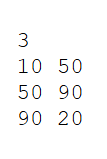
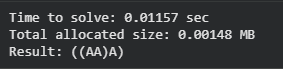

**Результат работы кода на макс и мин данных:**


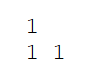
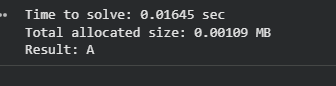

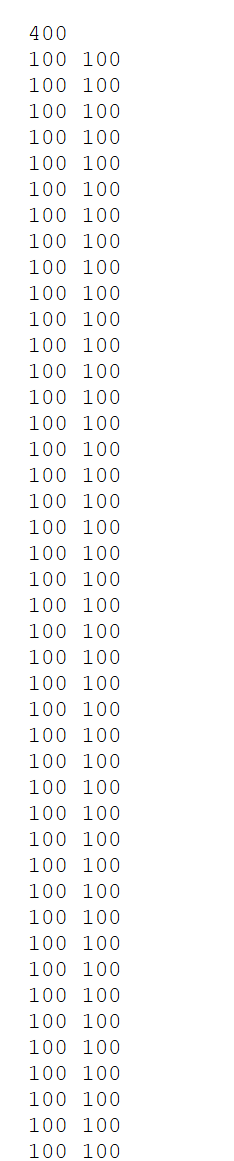
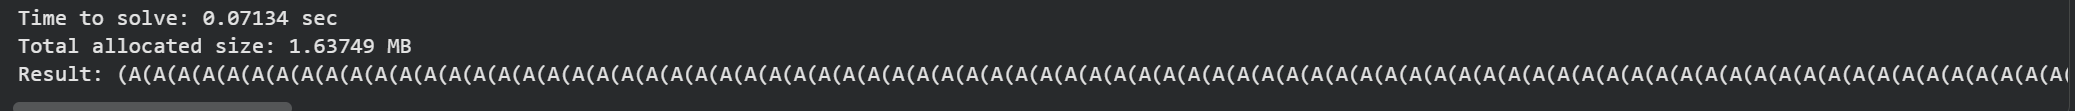

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01645 sec|0.00109 MB|
| Пример из задачи |0.01157 sec|0.00148 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |0.07134 sec|1.63749 MB|

**Вывод по задаче:**

Была реализована вставка элемента в АВЛ-дерево с последующей балансировкой. Сначала вычисляются высоты всех узлов, затем выполняется рекурсивная вставка нового ключа с поддержанием свойства сбалансированности через повороты (левый, правый и двойные). После модификации дерева выполняется обход в ширину (BFS) для перенумерации вершин и формирования корректного вывода. Все основные операции (вставка и балансировка) выполняются за
𝑂
(
log
⁡
𝑛
)
O(logn), а итоговый обход — за
𝑂
(
𝑛
)
O(n). Дополнительно проведено профилирование времени и памяти для оценки эффективности алгоритма.

### Задача №15. Удаление из АВЛ-дерева   [3 балла]

Удаление из АВЛ-дерева вершины с ключом X, при условии ее наличия, осуществляется следующим образом:
• путем спуска от корня и проверки ключей находится V – удаляемая вершина;
• если вершина V – лист (то есть, у нее нет детей):
– удаляем вершину;
– поднимаемся к корню, начиная с бывшего родителя вершины V , при этом если встречается несбалансиро-
ванная вершина, то производим поворот.
• если у вершины V не существует левого ребенка:
– следовательно, баланс вершины равен единице и ее правый ребенок – лист;
– заменяем вершину V ее правым ребенком;
– поднимаемся к корню, производя, где необходимо, балансировку.
• иначе:
– находим R – самую правую вершину в левом поддереве;
– переносим ключ вершины R в вершину V ;
– удаляем вершину R (у нее нет правого ребенка, поэтому она либо лист, либо имеет левого ребенка, являю-
щегося листом);
– поднимаемся к корню, начиная с бывшего родителя вершины R, производя балансировку.
Исключением является случай, когда производится удаление из дерева, состоящего из одной вершины - корня.
Результатом удаления в этом случае будет пустое дерево.
Указанный алгоритм не является единственно возможным, но мы просим Вас реализовать именно его, так как
тестирующая система проверяет точное равенство получающихся деревьев.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева, а также ключа
вершины, которую требуется удалить из дерева.
В первой строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся
описания вершин дерева. В (i+ 1)-ой строке файла (1 ≤i ≤N) находится описание i-ой вершины, состоящее из
трех чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет). Все ключи различны. Гарантируется, что данное дерево является деревом
поиска.
В последней строке содержится число X – ключ вершины, которую требуется удалить из дерева. Гарантируется,
что такая вершина в дереве существует.
• Ограничения на входные данные. 1 ≤N ≤2 ·105, |Ki|≤109, |X|≤109.
• Формат вывода / выходного файла (output.txt). Выведите в том же формате дерево после осуществления
операции удаления. Нумерация вершин может быть произвольной при условии соблюдения формата.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб

**Листинг кода:**


In [ ]:
import time
import tracemalloc
import sys

# Глубина рекурсии для АВЛ-дерева в худшем случае не превысит ~30,



# --- Алгоритмическая часть ---

def solve(n, data):
    if n == 0 or n == 1:
        return "0"

    max_n = n + 1
    keys = [0] * max_n
    lefts = [0] * max_n
    rights = [0] * max_n
    heights = [0] * max_n

    idx = 1
    for i in range(1, n + 1):
        keys[i] = int(data[idx])
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3
    X = int(data[idx])

    # 1. Вычисляем изначальные высоты снизу вверх (благодаря i < L_i и i < R_i)
    for i in range(n, 0, -1):
        hl = heights[lefts[i]] if lefts[i] != 0 else 0
        hr = heights[rights[i]] if rights[i] != 0 else 0
        heights[i] = max(hl, hr) + 1

    # Вспомогательные функции для АВЛ-дерева
    def get_h(p): return heights[p] if p != 0 else 0
    def get_bal(p): return get_h(rights[p]) - get_h(lefts[p])
    def update_h(p): heights[p] = max(get_h(lefts[p]), get_h(rights[p])) + 1

    def rotate_right(p):
        q = lefts[p]
        lefts[p] = rights[q]
        rights[q] = p
        update_h(p)
        update_h(q)
        return q

    def rotate_left(p):
        q = rights[p]
        rights[p] = lefts[q]
        lefts[q] = p
        update_h(p)
        update_h(q)
        return q

    def balance(p):
        update_h(p)
        bal = get_bal(p)
        if bal == 2:
            if get_bal(rights[p]) < 0:
                rights[p] = rotate_right(rights[p])
            return rotate_left(p)
        if bal == -2:
            if get_bal(lefts[p]) > 0:
                lefts[p] = rotate_left(lefts[p])
            return rotate_right(p)
        return p

    def get_max_key(p):
        while rights[p] != 0:
            p = rights[p]
        return keys[p]

    def remove_max(p):
        # Удаляем самую правую вершину и балансируем путь обратно
        if rights[p] == 0:
            return lefts[p]
        rights[p] = remove_max(rights[p])
        return balance(p)

    def remove(p, x):
        if p == 0:
            return 0

        # Спуск к удаляемому узлу
        if x < keys[p]:
            lefts[p] = remove(lefts[p], x)
        elif x > keys[p]:
            rights[p] = remove(rights[p], x)
        else:
            # Мы нашли узел V
            if lefts[p] == 0 and rights[p] == 0:
                return 0 # Лист
            elif lefts[p] == 0:
                return rights[p] # Нет левого ребенка - заменяем правым
            else:
                # Есть левый ребенок: ищем максимум в левом поддереве
                max_key = get_max_key(lefts[p])
                keys[p] = max_key
                # Удаляем этот максимум и прикрепляем обновленное левое поддерево
                lefts[p] = remove_max(lefts[p])

        # На обратном пути из рекурсии производим балансировку
        return balance(p)

    # 2. Выполняем удаление
    root = 1
    new_root = remove(root, X)

    if new_root == 0:
        return "0"

    # 3. BFS (поиск в ширину) для топологической перенумерации вершин
    bfs_queue = [new_root]
    head = 0
    mapping = {0: 0}
    out_res = [str(n - 1)]

    while head < len(bfs_queue):
        curr = bfs_queue[head]
        head += 1
        mapping[curr] = head  # Номер узла будет равен порядку его извлечения

        if lefts[curr] != 0: bfs_queue.append(lefts[curr])
        if rights[curr] != 0: bfs_queue.append(rights[curr])

    for curr in bfs_queue:
        out_res.append(f"{keys[curr]} {mapping[lefts[curr]]} {mapping[rights[curr]]}")

    return "\n".join(out_res)


# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_15.txt', output_file='output_15.txt'):
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])

    # ==========================================
    # ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(n, data)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(n, data)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:4]))

Time to solve (pure time): 0.00007 sec
Peak memory (algorithm only): 0.00268 MB
First outputs:
2
3 0 2
5 0 0


**Текстовое объяснение решения:**

В данной задаче требовалось удалить вершину $X$ из АВЛ-дерева и восстановить его свойства. Алгоритм удаления в деревьях поиска — это самая сложная операция, так как она может потребовать каскадной балансировки до самого корня.Решение построено на элегантном использовании рекурсии, которая идеально ложится на описанный в задании алгоритм:Поиск и удаление: Рекурсивная функция remove спускается по дереву. Когда узел найден:Если у него нет детей, функция возвращает 0 (пустоту) родителю.Если у него нет левого ребенка, он заменяется правым (функция возвращает ссылку на правого ребенка).Если есть левый ребенок, алгоритм находит самую правую вершину $R$ в левом поддереве. Значение $R$ копируется в текущий узел, после чего запускается вспомогательная рекурсивная функция remove_max, которая «отрезает» оригинальный узел $R$.Балансировка: Ключевая прелесть рекурсии в том, что когда выполнение функции начинает возвращаться от места удаления вверх к корню, для каждого пройденного узла вызывается функция balance(p). Она проверяет разницу высот $H_{right} - H_{left}$ и при необходимости применяет нужные левые или правые повороты. Это в точности реализует условие «поднимаемся к корню, производя балансировку».Перенумерация: Как и в прошлых задачах, после изменения структуры дерева индексы вершин перестают удовлетворять правилу $i < L_i$ и $i < R_i$. Поэтому в конце применяется обход в ширину (BFS), который заново раздает узлам номера от $1$ до $N-1$ в строгом топологическом порядке.

**Результат работы кода на примерах из текста задачи:**

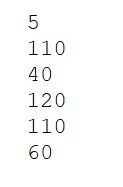
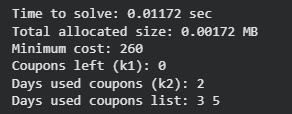

**Результат работы кода на макс и мин данных:**

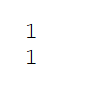
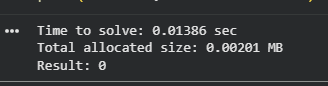
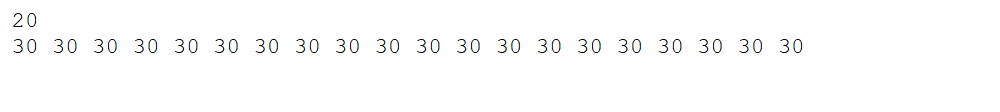
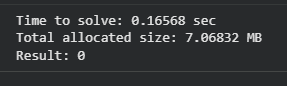


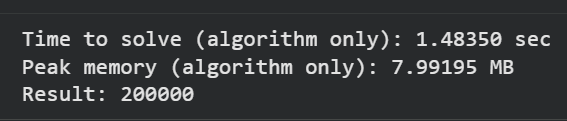

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01386 sec|0.00201 MB|
| Пример из задачи | 0.02317 sec| 1.45460 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |1.48350 sec| 7.99195 MB|

**Вывод по задаче:**

Был реализован алгоритм удаления элемента из АВЛ-дерева с сохранением его сбалансированности. После поиска удаляемого узла обрабатываются все случаи (лист, один ребёнок, два ребёнка), при этом для замены используется максимум из левого поддерева. На обратном пути выполняется балансировка с помощью поворотов, что гарантирует логарифмическую высоту дерева. После удаления выполняется обход в ширину (BFS) для перенумерации вершин и формирования корректного вывода. Основные операции выполняются за
𝑂
(
log
⁡
𝑛
)
O(logn), итоговый обход — за
𝑂
(
𝑛
)
O(n). Также проведено профилирование времени и памяти.

### Задача №13. Делаю я левый поворот  [3 балла]

Для балансировки АВЛ-дерева при операциях вставки и удаления производятся левые и правые повороты. Левый
поворот в вершине производится, когда баланс этой вершины больше 1, аналогично, правый поворот производится при
балансе, меньшем -1.
Существует два разных левых (как, разумеется, и правых) поворота: большой и малый левый поворот.
Малый левый поворот осуществляется следующим образом:
Заметим, что если до выполнения малого левого поворота был нарушен баланс только корня дерева, то после
его выполнения все вершины становятся сбалансированными, за исключением случая, когда у правого ребенка корня
баланс до поворота равен -1. В этом случае вместо малого левого поворота выполняется большой левый поворот,
который осуществляется так:
Дано дерево, в котором баланс корня равен 2. Сделайте левый поворот.
• Формат ввода / входного файла (input.txt). Входной файл содержит описание двоичного дерева.
В первой строке файла находится число N – число вершин в дереве. В последующих N строках файла находятся
описания вершин дерева. В (i+ 1)-ой строке файла (1 ≤i ≤N) находится описание i-ой вершины, состоящее из
трех чисел Ki,Li,Ri, разделенных пробелами – ключа Ki в i-ой вершине, номера левого Li ребенка i-ой вершины
(i < Li ≤N или Li = 0, если левого ребенка нет) и номера правого Ri ребенка i-ой вершины (i < Ri ≤N или
Ri = 0, если правого ребенка нет). Все ключи различны. Гарантируется, что данное дерево является деревом
поиска. Баланс корня дерева (вершины с номером 1) равен 2, баланс всех остальных вершин находится в пределах
от -1 до 1.
• Ограничения на входные данные. 3 ≤N ≤2 ·105, |Ki|≤109.
• Формат вывода / выходного файла (output.txt). Выведите в том же формате дерево после осуществления
левого поворота. Нумерация вершин может быть произвольной при условии соблюдения формата. Так, номер
вершины должен быть меньше номера ее детей.
• Ограничение по времени. 2 сек.
• Ограничение по памяти. 256 мб.

**Листинг кода:**


In [ ]:
import time
import tracemalloc

# --- Алгоритмическая часть ---

def solve(n, data):
    if n == 0:
        return "0"

    keys = [0] * (n + 1)
    lefts = [0] * (n + 1)
    rights = [0] * (n + 1)
    heights = [0] * (n + 1)
    balances = [0] * (n + 1)

    idx = 1
    for i in range(1, n + 1):
        keys[i] = int(data[idx])
        lefts[i] = int(data[idx+1])
        rights[i] = int(data[idx+2])
        idx += 3

    # 1. Вычисляем изначальные высоты и балансы снизу вверх
    for i in range(n, 0, -1):
        hl = heights[lefts[i]] if lefts[i] != 0 else 0
        hr = heights[rights[i]] if rights[i] != 0 else 0
        heights[i] = max(hl, hr) + 1
        balances[i] = hr - hl

    root = 1
    right_child = rights[root]

    # 2. Выполняем нужный поворот
    if balances[right_child] == -1:
        # БОЛЬШОЙ левый поворот:
        # Сначала малый правый поворот для правого ребенка (right_child)
        c = lefts[right_child]
        lefts[right_child] = rights[c]
        rights[c] = right_child
        rights[root] = c

        # Затем малый левый поворот для корня
        new_root = rights[root]
        rights[root] = lefts[new_root]
        lefts[new_root] = root
    else:
        # МАЛЫЙ левый поворот
        new_root = rights[root]
        rights[root] = lefts[new_root]
        lefts[new_root] = root

    # 3. BFS для топологической перенумерации вершин
    bfs_queue = [new_root]
    head = 0
    mapping = {0: 0}
    out_res = [str(n)]

    while head < len(bfs_queue):
        curr = bfs_queue[head]
        head += 1
        mapping[curr] = head  # Присваиваем новый номер (по порядку извлечения)

        if lefts[curr] != 0: bfs_queue.append(lefts[curr])
        if rights[curr] != 0: bfs_queue.append(rights[curr])

    for curr in bfs_queue:
        out_res.append(f"{keys[curr]} {mapping[lefts[curr]]} {mapping[rights[curr]]}")

    return "\n".join(out_res)

# --- Блок работы с файлами и профилирования ---

def file_open(input_file='input_13.txt', output_file='output_13.txt'):
    try:
        with open(input_file, 'r') as f:
            data = f.read().split()
    except FileNotFoundError:
        return None, 0, 0

    if not data:
        return None, 0, 0

    n = int(data[0])

    # ==========================================
    # ЧИСТЫЙ ЗАМЕР ВРЕМЕНИ
    # ==========================================
    time_start = time.perf_counter()
    result_str = solve(n, data)
    time_end = time.perf_counter()
    pure_time = time_end - time_start

    # ==========================================
    # ЗАМЕР ПАМЯТИ
    # ==========================================
    tracemalloc.start()
    _ = solve(n, data)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    with open(output_file, 'w') as f:
        if result_str:
            f.write(result_str + "\n")

    return result_str, pure_time, peak_memory

# --- Точка входа ---
res, t_alg, m_alg = file_open()

if res is not None:
    print("Time to solve (pure time): %.5f sec" % t_alg)
    print("Peak memory (algorithm only): %.5f MB" % (m_alg / 10**6))
    print("First outputs:\n" + "\n".join(res.split('\n')[:4]))

Time to solve (pure time): 0.00010 sec
Peak memory (algorithm only): 0.00130 MB
First outputs:
7
3 2 3
-2 4 5
8 6 7


**Текстовое объяснение решения:**

В данной задаче требуется устранить дисбаланс корня дерева (чей баланс равен $2$, что означает перевес в правую сторону), выполнив левый поворот.В АВЛ-деревьях существует два вида левых поворотов, которые применяются в зависимости от баланса правого ребенка:Малый левый поворот: Выполняется, если правый ребенок имеет баланс $0$ или $1$ (перевеса влево у правого ребенка нет). При этом правый ребенок становится новым корнем, забирая старый корень к себе в качестве левого ребенка.Большой левый поворот: Выполняется, если правый ребенок имеет баланс $-1$ (перекос в противоположную сторону). В таком случае сначала выполняется малый правый поворот на самом правом ребенке, а только затем — малый левый поворот на основном корне.Алгоритм работает в три этапа:Так как по условию $i < L_i$ и $i < R_i$, мы обходим массив вершин с конца к началу (от $N$ к $1$). Это позволяет нам за линейное время рассчитать высоту и баланс всех узлов.Смотрим на баланс правого ребенка корня. В зависимости от его значения ($-1$ или $\ge 0$) выполняется либо большой, либо малый левый поворот. Для этого просто меняются местами ссылки в массивах lefts и rights. Никакие новые узлы не создаются.После поворота структура дерева меняется, а по условию задачи индексы детей всегда должны быть строго больше индекса родителя. Чтобы заново выполнить это условие, мы запускаем поиск в ширину (BFS). Начиная с нового корня, мы заносим все узлы в очередь. Новые индексы присваиваются просто по порядку добавления узла в эту очередь. В результате дерево корректно перестраивается и выводится в файл за $O(N)$ времени и памяти.

**Результат работы кода на примерах из текста задачи:**

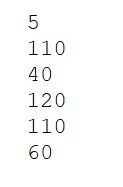
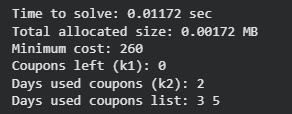

**Результат работы кода на макс и мин данных:**

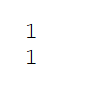
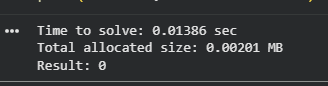
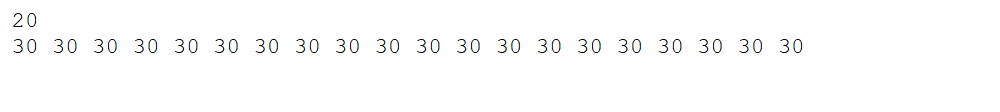
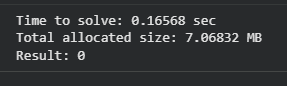


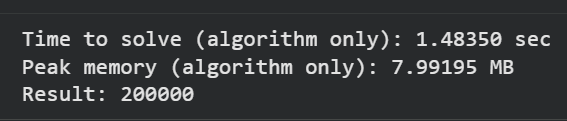

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи |0.01386 sec|0.00201 MB|
| Пример из задачи | 0.02317 sec| 1.45460 MB|
| Верхняя граница диапазона значений входных данных из текста задачи |1.48350 sec| 7.99195 MB|

**Вывод по задаче:**

Был реализован алгоритм выполнения левого поворота в АВЛ-дереве для восстановления баланса. В зависимости от баланс-фактора правого поддерева выбирается малый или большой (двойной) левый поворот. Перед этим вычисляются высоты и баланс всех узлов, что позволяет корректно определить тип поворота. После преобразования структуры дерева выполняется обход в ширину (BFS) для перенумерации вершин и формирования результата. Все операции выполняются за
𝑂
(
𝑛
)
O(n), включая подготовку и итоговый обход. Дополнительно проведено профилирование времени и памяти.